In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar el dataset limpio
df = pd.read_csv('../documents/data/clean/RelacionesPersonales(limpio).csv')

# El número de cuenta es un identificador, no aporta al modelo de clustering
# Lo guardamos como índice para no perder a quién pertenece cada registro
if 'num_cuenta' in df.columns:
    df.set_index('num_cuenta', inplace=True)

print(f"El dataset tiene {df.shape[0]} filas registros y {df.shape[1]} columnas.")
display(df.head())

El dataset tiene 14 filas registros y 13 columnas.


,confianzaInterpersonal,habilidadSocial,amigos,tiempoLibre,enfoque,noviazgo,tiempoSoltero,participacion,comunicacion,colaborativo,integracion,inciativaInteraccional,energiaInterpersonal
num_cuenta,,,,,,,,,,,,,
422018647,"confianza, seguridad emocional",2,1,"salir con amigos, descanso en casa",1,1,0.0,0,1,1,5.0,tema en comun,4
317127133,"sin juicio, confianza",3,1,drink chiava,0,1,2.0,1,1,1,4.0,"hacer preguntas, tema en comun",3
422041654,"seguridad emocional, confianza, sin juicio",5,0,"pareja, descanso en casa, salir con amigos",0,1,0.0,2,1,0,NaN,hacer preguntas,3
317237896,alguien conocer ver malo decidir acompañarte a...,4,0,carnita asado escalar cerro,0,0,2.0,2,1,1,2.0,hacer preguntas,5
320014406,"confianza, seguridad emocional",3,1,salir con amigos,1,0,1.0,0,1,1,4.0,saludandolo,1


--- Variables Numéricas (Escalas/Conteos) ---
['habilidadSocial', 'amigos', 'enfoque', 'noviazgo', 'tiempoSoltero', 'participacion', 'comunicacion', 'colaborativo', 'integracion', 'energiaInterpersonal']

--- Variables Categóricas (Texto Libre/Opciones) ---
['confianzaInterpersonal', 'tiempoLibre', 'inciativaInteraccional']


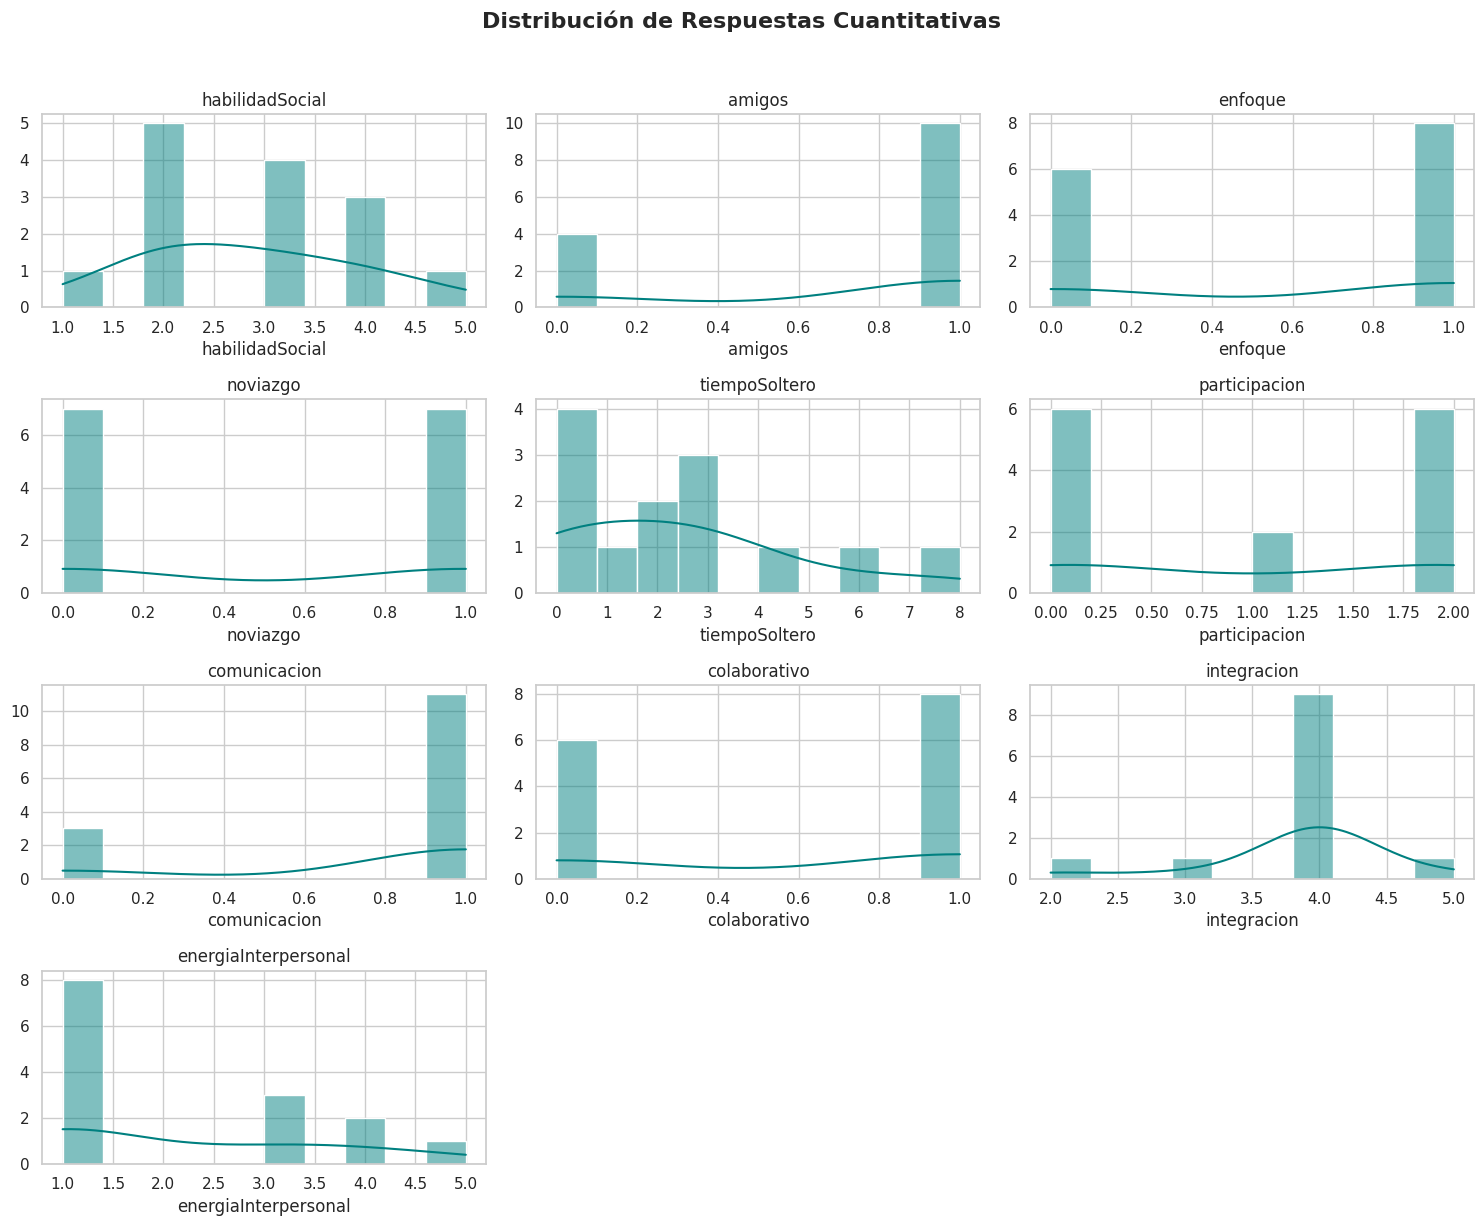

In [12]:
# Separamos las columnas son numéricas y las que son texto (categóricas)
vars_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
vars_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("--- Variables Numéricas (Escalas/Conteos) ---")
print(vars_numericas)
print("\n--- Variables Categóricas (Texto Libre/Opciones) ---")
print(vars_categoricas)

# Creamos histogramas para ver cómo se distribuyen las variables numéricas
fig = plt.figure(figsize=(15, 12))
fig.suptitle('Distribución de Respuestas Cuantitativas', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(vars_numericas, 1):
    ax = fig.add_subplot(4, 3, i) # Ajusta el (4,3) dependiendo de cuántas variables sean
    sns.histplot(df[col], kde=True, color='teal', bins=10, ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

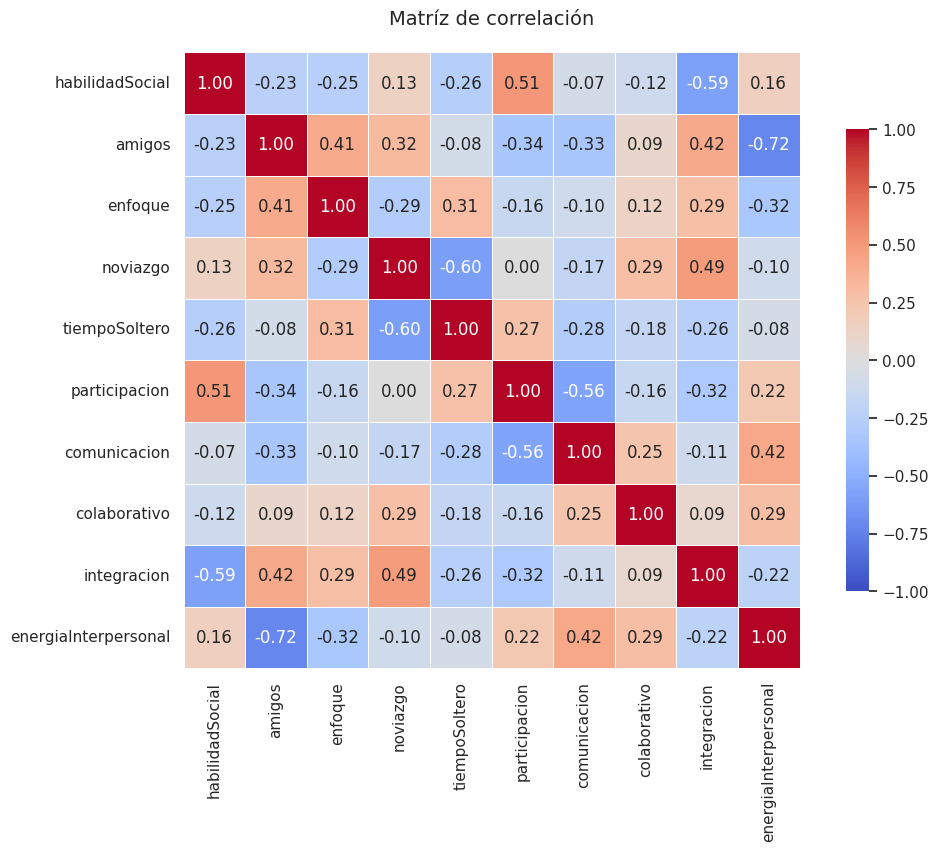

Generando matriz de dispersión


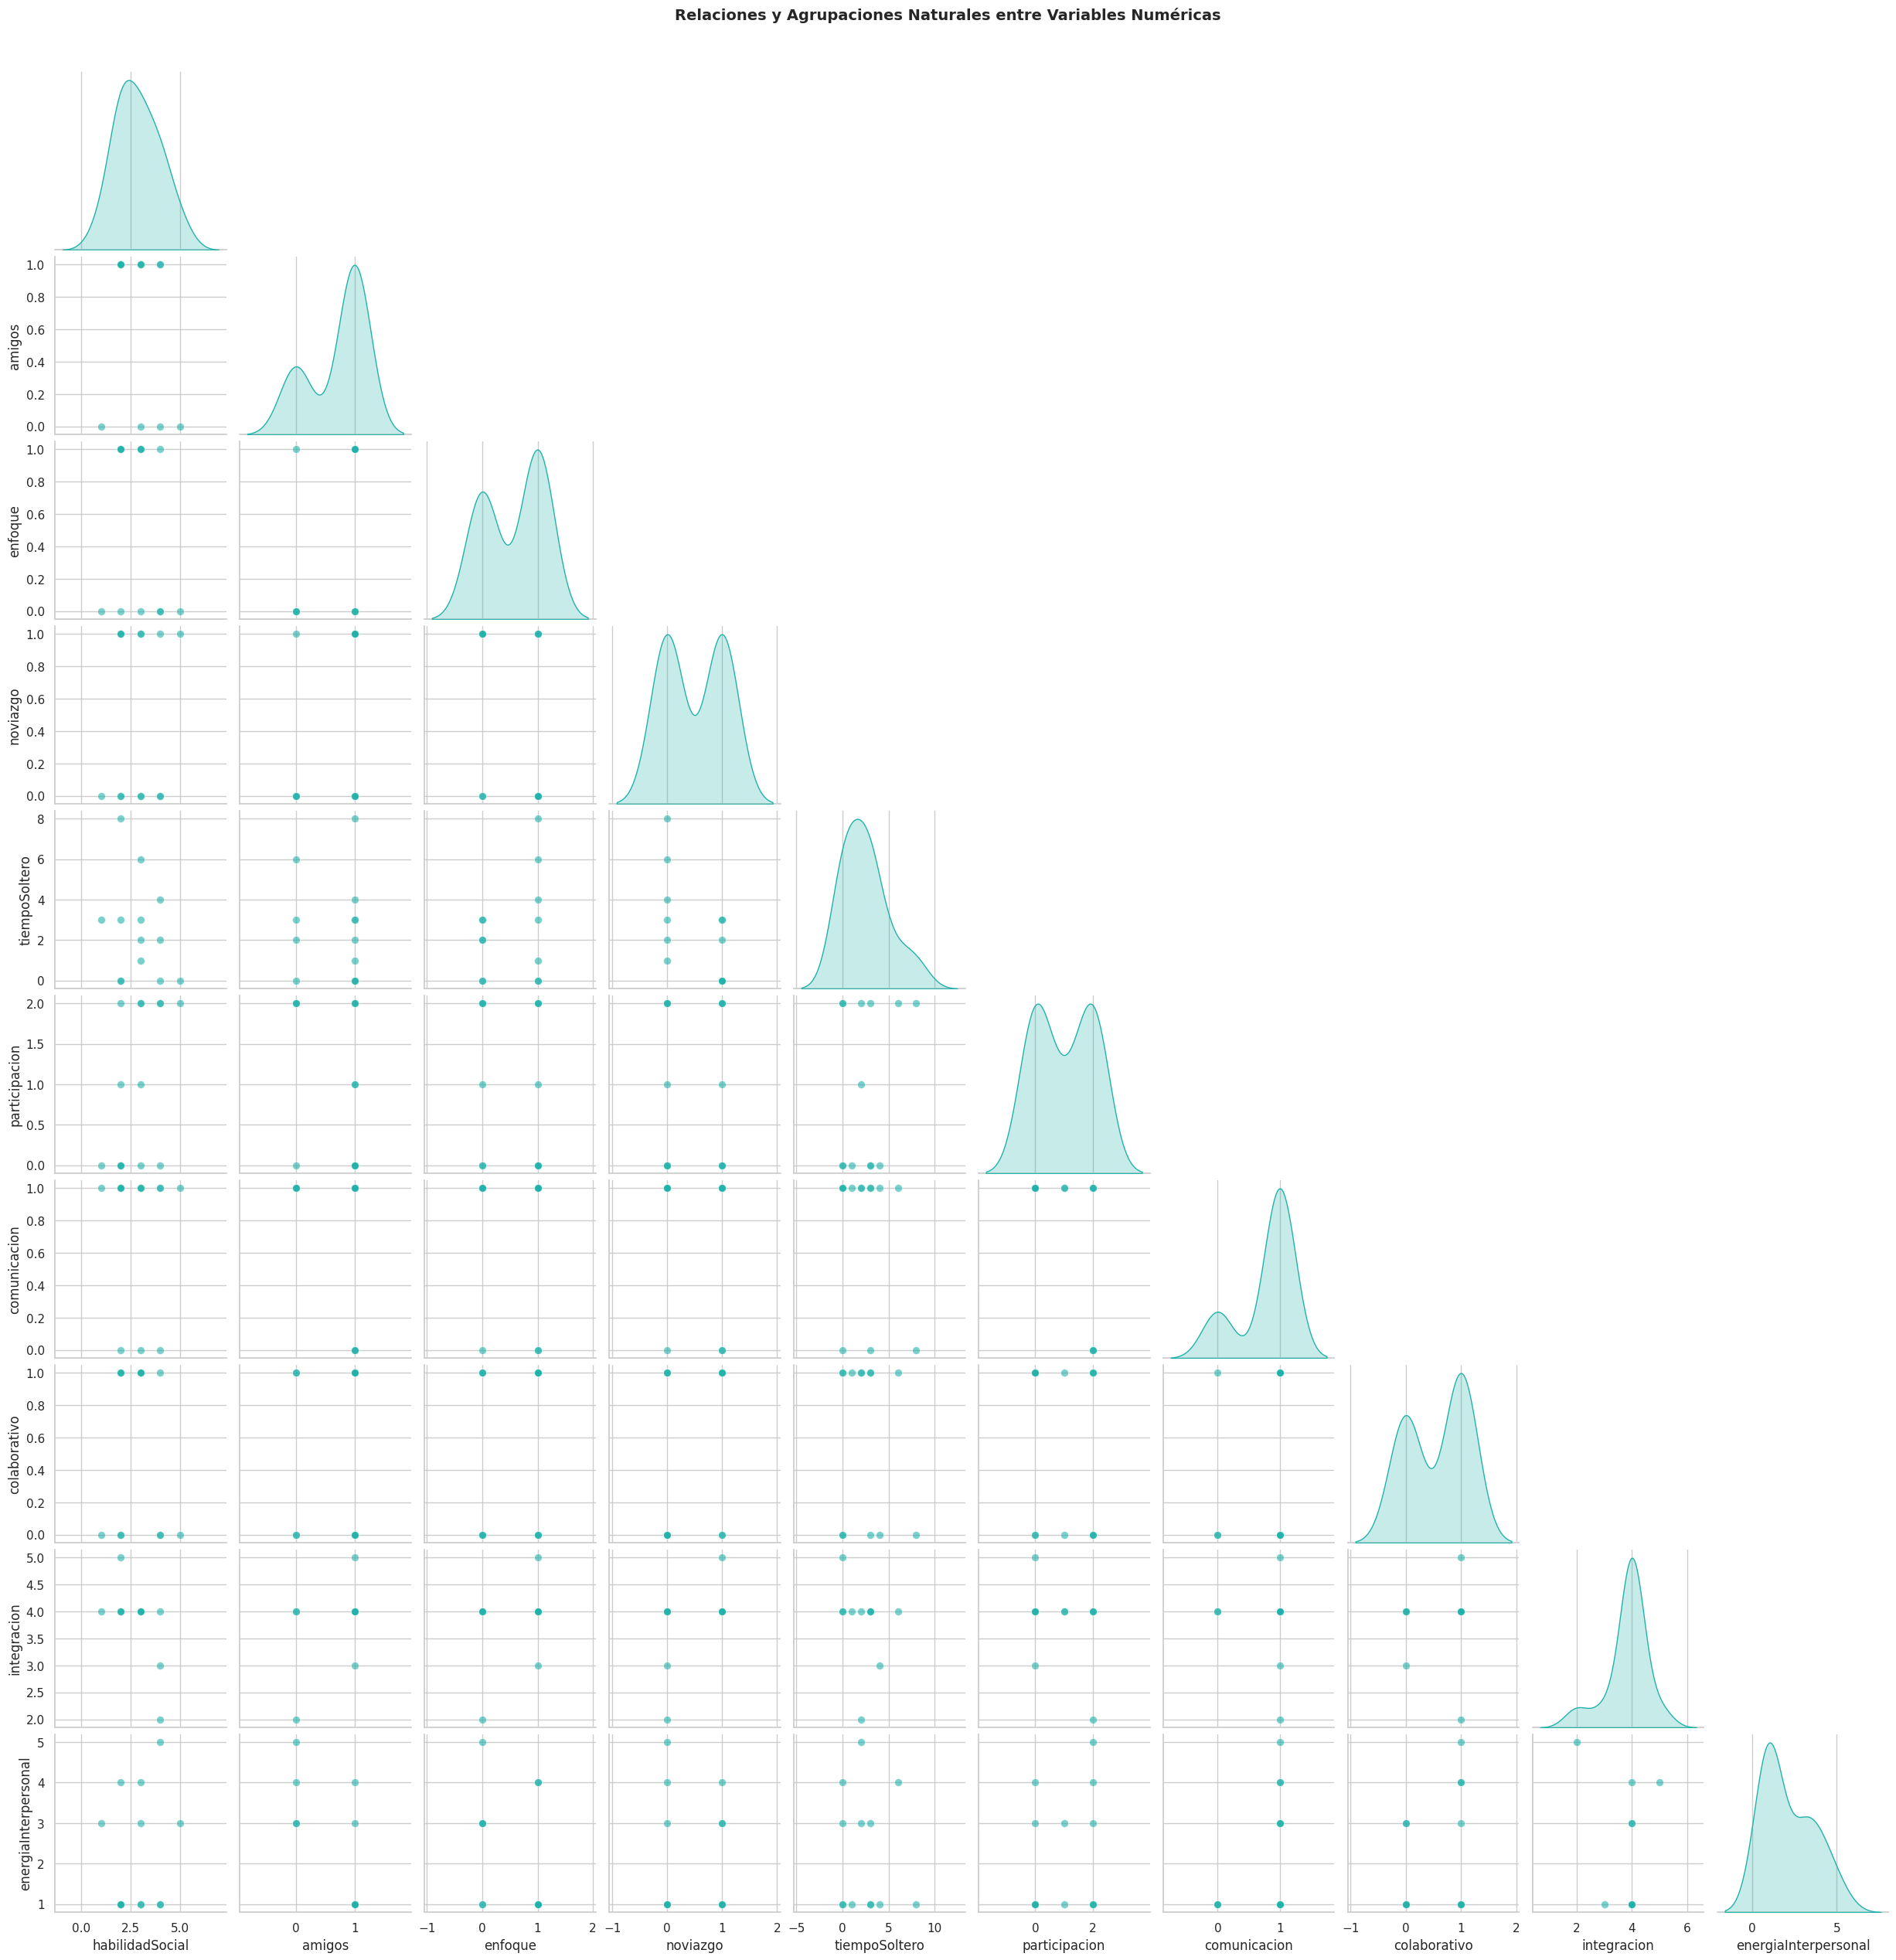

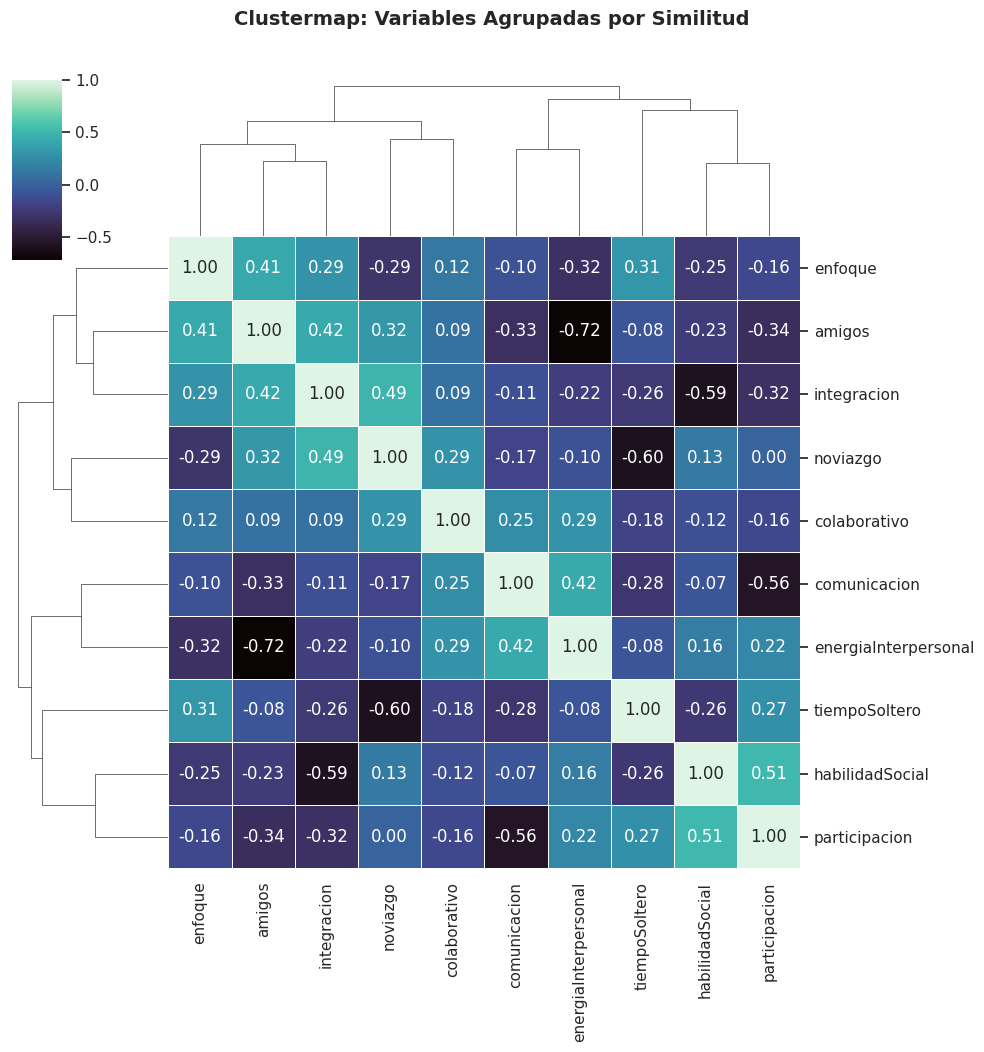

In [13]:
# Veremos si hay relación directa entre variables
# Por ejemplo: si tienes buena 'comunicacion', ¿tienes alta 'habilidadSocial'?
plt.figure(figsize=(12, 8))
matriz_corr = df[vars_numericas].corr()

# Matriz de correlación
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Matríz de correlación', fontsize=14, pad=20)
plt.show()

# Matriz de dispersión
print("Generando matriz de dispersión")

# Usamos corner=True para no repetir las gráficas y diag_kind='kde' para ver las curvas suaves
g = sns.pairplot(df[vars_numericas],
                 corner=True,
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'w', 'color': '#20B2AA'},
                 diag_kws={'color': '#20B2AA', 'fill': True})

g.fig.suptitle('Relaciones y Agrupaciones Naturales entre Variables Numéricas', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Un clustermap (matriz de correlación pero en lugar de hacerlo por columnas, lo hace por grupos o clusters)
# Calculamos la matriz de correlación de nuevo
corr_matrix = df[vars_numericas].corr()

# Creamos el Clustermap
g_cluster = sns.clustermap(corr_matrix,
                           annot=True,
                           fmt=".2f",
                           cmap="mako",
                           figsize=(10, 10),
                           linewidths=.5,
                           cbar_pos=(0.02, 0.8, 0.05, 0.18)) # Ajustamos la barra de color

plt.setp(g_cluster.ax_heatmap.get_yticklabels(), rotation=0)
g_cluster.fig.suptitle('Clustermap: Variables Agrupadas por Similitud', y=1.05, fontsize=14, fontweight='bold')
plt.show()

In [14]:
# Columnas que no son numéricas (confianzaInterpersonal, tiempoLibre, inciativaInteraccional)
print("Preparando datos para Machine Learning")

# Separamos las variables numéricas (para el modelo) de las de texto (para perfilar después)
# Ignoramos la columna 0 si se usó como índice
df_modelo = df[vars_numericas].copy()

# Rellenamos valores nulos numéricos (si los hay) con la mediana para no perder el registro
df_modelo = df_modelo.fillna(df_modelo.median())

# Estandarización (Regla de oro del Clustering)
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_modelo)
df_escalado = pd.DataFrame(datos_escalados, columns=df_modelo.columns, index=df_modelo.index)

print(f"El dataset de entrenamiento tiene {df_escalado.shape[0]} filas y {df_escalado.shape[1]} columnas.")
display(df_escalado.head(3))

Preparando datos para Machine Learning
El dataset de entrenamiento tiene 14 filas y 10 columnas.


,habilidadSocial,amigos,enfoque,noviazgo,tiempoSoltero,participacion,comunicacion,colaborativo,integracion,energiaInterpersonal
num_cuenta,,,,,,,,,,
422018647,-0.80904,0.632456,0.866025,1.0,-1.060431,-1.080123,0.522233,0.866025,1.788854,1.319950
317127133,0.13484,0.632456,-1.154701,1.0,-0.187135,0.000000,0.522233,0.866025,0.223607,0.609208
422041654,2.02260,-1.581139,-1.154701,1.0,-1.060431,1.080123,0.522233,-1.154701,0.223607,0.609208


Calculando Inercia y Silhouette Score para k entre 2 y 6...


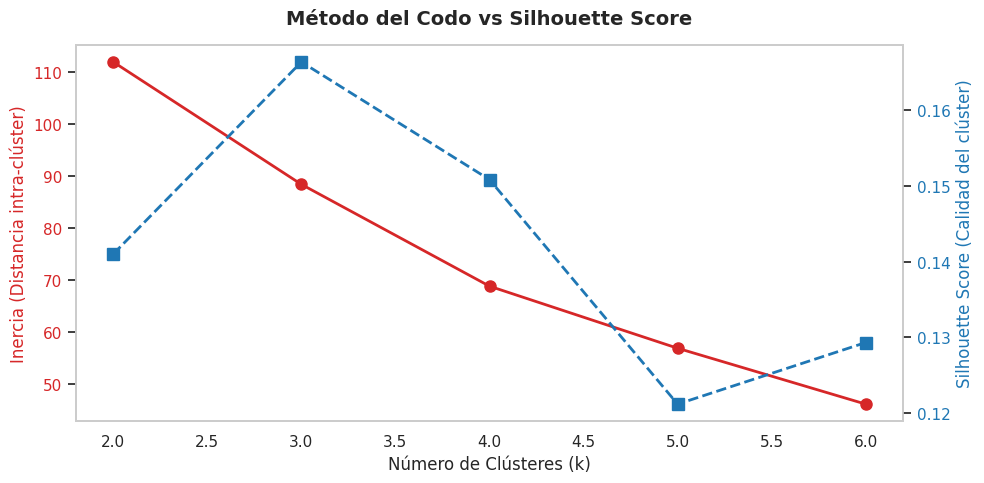

In [15]:
# Buscamos el número de clusters a usar en k-means por
# Método del Codo (Inercia) y El Coeficiente de Silueta

print("Calculando Inercia y Silhouette Score para k entre 2 y 6...")

inercia = []
silueta = []
rango_k = range(2, 7) # Probamos de 2 a 6 grupos

for k in rango_k:
    # random_state=42 asegura que si lo corren 100 veces, siempre de el mismo resultado
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(df_escalado)

    inercia.append(kmeans_temp.inertia_)
    silueta.append(silhouette_score(df_escalado, kmeans_temp.labels_))

# Graficas para guiarnos en la elección
fig, ax1 = plt.subplots(figsize=(10, 5))

# Método del Cod
color = 'tab:red'
ax1.set_xlabel('Número de Clústeres (k)', fontsize=12)
ax1.set_ylabel('Inercia (Distancia intra-clúster)', color=color, fontsize=12)
ax1.plot(rango_k, inercia, marker='o', color=color, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(False)

# Coeficiente de Silueta (en el mismo eje X)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score (Calidad del clúster)', color=color, fontsize=12)
ax2.plot(rango_k, silueta, marker='s', linestyle='--', color=color, linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(False)

plt.title('Método del Codo vs Silhouette Score', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

La línea roja (Codo): Buscamos el punto donde la línea deja de caer drásticamente y hace un doblez (como un codo).

La línea azul (Silueta): Mide qué tan bien separados están los grupos. Buscamos el punto más alto.

Modelo K-Means entrenado con 3 clústeres.
         Número de Personas
Clúster                    
0                         9
1                         2
2                         3


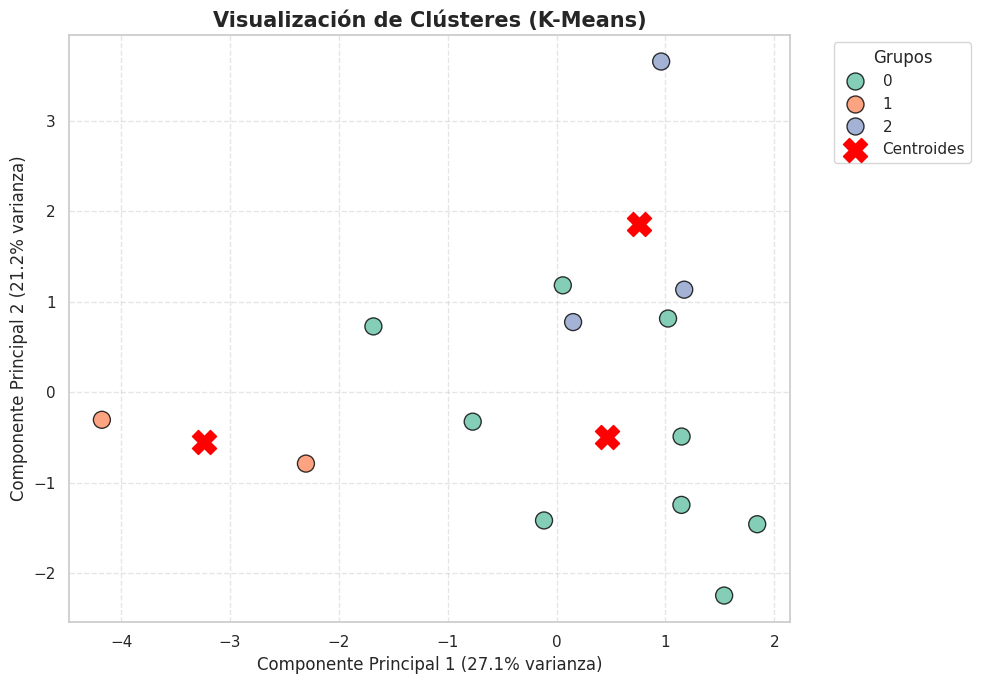

In [16]:
# k-means

k_elegido = 3  # de acuerdo con las graficas de arriba, tomaremos a k = 3
kmeans_final = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans_final.fit_predict(df_escalado) # Guardamos la etiqueta en el df original

print(f"Modelo K-Means entrenado con {k_elegido} clústeres.")
print(df['Cluster_KMeans'].value_counts().sort_index().rename_axis('Clúster').to_frame('Número de Personas'))

# reducción de dimensionalidad
pca = PCA(n_components=2) #Para graficar en X y Y
componentes = pca.fit_transform(df_escalado)

df_pca = pd.DataFrame(data=componentes, columns=['Componente_1', 'Componente_2'])
df_pca['Cluster'] = df['Cluster_KMeans'].values

# Graficar clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Componente_1', y='Componente_2', hue='Cluster', data=df_pca,
                palette='Set2', s=150, edgecolor='black', alpha=0.8)

# Dibujamos los centroides
centroides_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            c='red', s=300, marker='X', label='Centroides')

plt.title('Visualización de Clústeres (K-Means)', fontsize=15, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.legend(title='Grupos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
# Perfilamiento de los clusters
print("Iniciando el perfilamiento de los 3 grupos encontrados\n")

# Promedios de los clusters
print("PROMEDIOS DE VARIABLES NUMÉRICAS POR CLÚSTER")
# Agrupamos por el clúster y sacamos el promedio, redondeado a 2 decimales
perfil_numerico = df.groupby('Cluster_KMeans')[vars_numericas].mean().round(2)

# Transponemos la tabla (.T) para que los clústeres queden arriba y sea más fácil compararlos
display(perfil_numerico.T)

print("\n" + "="*50 + "\n")

# Respuestas más frecuentes
print("RESPUESTAS DE TEXTO MÁS FRECUENTES POR CLÚSTER")
# Iteramos sobre cada uno de los 3 grupos
for cluster in range(3):
    cantidad = len(df[df['Cluster_KMeans'] == cluster])
    print(f"\n>> CLÚSTER {cluster} (Tamaño: {cantidad} personas)")

    for col in vars_categoricas:
        # Buscamos la moda (lo que más se repite) en las variables de texto
        moda = df[df['Cluster_KMeans'] == cluster][col].mode()

        # Como puede haber empates, tomamos el primer valor
        if not moda.empty:
            texto_frecuente = moda.iloc[0]
            print(f"   - {col}: {texto_frecuente}")

Iniciando el perfilamiento de los 3 grupos encontrados

PROMEDIOS DE VARIABLES NUMÉRICAS POR CLÚSTER


Cluster_KMeans,0,1,2
habilidadSocial,2.44,4.5,3.00
amigos,0.78,0.0,1.00
enfoque,0.67,0.0,0.67
noviazgo,0.44,0.5,0.67
tiempoSoltero,2.38,1.0,3.67
participacion,0.44,2.0,2.00
comunicacion,1.00,1.0,0.00
colaborativo,0.67,0.5,0.33
integracion,4.00,2.0,4.00
energiaInterpersonal,2.11,4.0,1.00




RESPUESTAS DE TEXTO MÁS FRECUENTES POR CLÚSTER

>> CLÚSTER 0 (Tamaño: 9 personas)
   - confianzaInterpersonal: confianza
   - tiempoLibre: salir con amigos
   - inciativaInteraccional: hacer preguntas

>> CLÚSTER 1 (Tamaño: 2 personas)
   - confianzaInterpersonal: alguien conocer ver malo decidir acompañarte apoyarte
   - tiempoLibre: carnita asado escalar cerro
   - inciativaInteraccional: hacer preguntas

>> CLÚSTER 2 (Tamaño: 3 personas)
   - confianzaInterpersonal: confianza, seguridad emocional
   - tiempoLibre: descanso en casa, familia, pareja
   - inciativaInteraccional: hacer preguntas


In [19]:
# OPTIMIZACIÓN DE K-MEANS (GridSearch y RandomSearch)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

print("Iniciando optimización de hiperparámetros para K-Means...\n")

# Le pasamos los índices (0 al 13)
indices_completos = list(range(len(df_escalado)))
cv_custom = [(indices_completos, indices_completos)]

# Definimos para K-Means
parametros_busqueda = {
    'n_clusters': [2, 3, 4, 5],
    'init': ['k-means++', 'random'],
    'n_init': [10, 20, 30],
    'algorithm': ['lloyd', 'elkan']
}

kmeans_base = KMeans(random_state=42)

# GridSearchCV
print("--- 1. Ejecutando GridSearchCV ---")
grid_search = GridSearchCV(estimator=kmeans_base,
                           param_grid=parametros_busqueda,
                           cv=cv_custom,
                           n_jobs=-1)

grid_search.fit(df_escalado)
print("¡GridSearch terminado!")
print(f"Mejor combinación encontrada: {grid_search.best_params_}\n")


# RandomizedSearchCV
print("--- 2. Ejecutando RandomizedSearchCV ---")
random_search = RandomizedSearchCV(estimator=kmeans_base,
                                   param_distributions=parametros_busqueda,
                                   n_iter=10,
                                   cv=cv_custom,
                                   random_state=42,
                                   n_jobs=-1)

random_search.fit(df_escalado)
print("¡RandomizedSearch terminado!")
print(f"Mejor combinación encontrada: {random_search.best_params_}")

Iniciando optimización de hiperparámetros para K-Means...

--- 1. Ejecutando GridSearchCV ---
¡GridSearch terminado!
Mejor combinación encontrada: {'algorithm': 'lloyd', 'init': 'k-means++', 'n_clusters': 5, 'n_init': 10}

--- 2. Ejecutando RandomizedSearchCV ---
¡RandomizedSearch terminado!
Mejor combinación encontrada: {'n_init': 20, 'n_clusters': 4, 'init': 'random', 'algorithm': 'elkan'}


Interpretación Analítica de la Optimización (GridSearchCV vs Análisis Visual).

Tras ejecutar la búsqueda exhaustiva (GridSearch) y la búsqueda aleatoria (RandomSearch), los algoritmos sugirieron la formación de 5 y 4 clústeres respectivamente, ya que matemáticamente esto minimiza la inercia (la distancia entre los puntos y su centroide).

Sin embargo, tomamos la decisión de mantener el modelo final en k=3. La justificación radica en el tamaño de la muestra (n=14). Si creamos 4 o 5 grupos para tan pocos registros podríamos llegar al sobreajuste (overfitting), creando subgrupos de una sola persona que carecen de valor estadístico y de negocio para nuestra propuesta de mercado.